In [6]:
# Imports
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder

# Local project paths for VS Code.
# Open credit_risk_project as the VS Code workspace folder.
project_dir = Path.cwd()

train_dir = project_dir / "train"
test_dir = project_dir / "test"

print("Project directory:", project_dir)
print("Train folder found:", train_dir.exists())
print("Test folder found:", test_dir.exists())

assert train_dir.exists(), f"Missing train directory: {train_dir}"
assert test_dir.exists(), f"Missing test directory: {test_dir}"



Project directory: /Users/skylarroberts/Applications/Copy Of Amex Project On VS Code/American-Express-1C-second-look-lending
Train folder found: False
Test folder found: False


AssertionError: Missing train directory: /Users/skylarroberts/Applications/Copy Of Amex Project On VS Code/American-Express-1C-second-look-lending/train

In [2]:
# Import the necessary tools for the data tables and Preprocessing
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder



def load_csvs(folder, pattern):
    """Load and combine all CSV files that match a filename pattern."""
    files = sorted(folder.glob(pattern))

    if not files:
        raise FileNotFoundError(
            f"No files were found using: {pattern}\n"
            f"Folder checked: {folder}"
        )

    print(f"\nFiles loaded for {pattern}:")
    for file in files:
        print(" -", file.name)

    dataframes = [
        pd.read_csv(file, low_memory=False)
        for file in files
    ]

    return pd.concat(dataframes, ignore_index=True)


# Loads the base data tables has one row per applicant.
train_base = pd.read_csv(
    train_dir / "train_base.csv",
    low_memory=False
)

test_base = pd.read_csv(
    test_dir / "test_base.csv",
    low_memory=False
)

"""
Load the related and relevant source tables. Note that ehese source tables
may be split across multiple CSV files.
"""
static_train = load_csvs(
    train_dir,
    "train_static_0_*.csv"
)

static_test = load_csvs(
    test_dir,
    "test_static_0_*.csv"
)

static_cb_train = load_csvs(
    train_dir,
    "train_static_cb_0*.csv"
)

static_cb_test = load_csvs(
    test_dir,
    "test_static_cb_0*.csv"
)

bureau_train = load_csvs(
    train_dir,
    "train_credit_bureau_a_1*.csv"
)

bureau_test = load_csvs(
    test_dir,
    "test_credit_bureau_a_1*.csv"
)


def quick_eda(df, name):
    """
    Print or show the shapes, duplicate IDs, missing values, and column types.
    """
    # The code below creates line boundary
    print(f"\n{'=' * 70}")
    print(name)
    print(f"Shape: {df.shape}")

    if "case_id" in df.columns:
        print(f"Unique case_id values: {df['case_id'].nunique():,}")
        print(
            "Duplicate case_id rows:",
            f"{df['case_id'].duplicated().sum():,}"
        )

    if "target" in df.columns:
        print(f"Target default rate: {df['target'].mean():.4f}")


    print("\nTop 10 columns by missingness:")
    print(
        df.isna()
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    print("\nColumn types:")
    print(df.dtypes.value_counts())

# Review and check source tables before merging.
quick_eda(train_base, "TRAIN BASE")
quick_eda(static_train, "STATIC_0 TRAIN")
quick_eda(static_cb_train, "STATIC_CB_0 TRAIN")
quick_eda(bureau_train, "CREDIT_BUREAU_A_1 TRAIN")

"""
 Assert checks and evaulates that a condition is True. If the condition is False
 then Python stops and raises or gives an AssertionError. Here, we confirm and
 reinforce that depth-0 tables have one row per applicant before merging. Not to
 mention, this prevents accidentally duplicating the applicant rows after
 the joins and merging.
"""

"""
Confirm and finalize that the depth-0 tables have one row per applicant
before merging.
"""

assert train_base["case_id"].is_unique, (
    "train_base should have one row per case_id."
)

assert test_base["case_id"].is_unique, (
    "test_base should have one row per case_id."
)

assert static_train["case_id"].is_unique, (
    "static_train has duplicate case_id values."
)

assert static_test["case_id"].is_unique, (
    "static_test has duplicate case_id values."
)

assert static_cb_train["case_id"].is_unique, (
    "static_cb_train has duplicate case_id values."
)

assert static_cb_test["case_id"].is_unique, (
    "static_cb_test has duplicate case_id values."
)

print("\nDepth-0 table checks passed.")


def aggregate_depth_1(df, prefix="bureau_a"):
    """
    Aggregate a depth-1 table so that each case_id has one summary row.

    Raw bureau data can contain multiple records per applicant, so merging it
    directly would duplicate applicants in the modeling dataset.
    """
    numeric_cols = [
        col
        for col in df.select_dtypes(include="number").columns
        if col != "case_id"
    ]
    """
    Record count could potentially capture how much bureau history
    an applicant has.
    So the code below counts the bureau records for each applicant
    """
    result = (
        df.groupby("case_id")
        .size()
        .rename(f"{prefix}_record_count")
        .to_frame()
    )
    # Creates the numeric summaries for each applicant.
    if numeric_cols:
        numeric_summary = (
            df.groupby("case_id")[numeric_cols]
            .agg(["count", "mean", "max", "min", "sum"])
        )

        numeric_summary.columns = [
            f"{prefix}_{column}_{statistic}"
            for column, statistic in numeric_summary.columns
        ]

        result = result.join(numeric_summary)

    return result.reset_index()


bureau_train_agg = aggregate_depth_1(
    bureau_train,
    prefix="bureau_a"
)

bureau_test_agg = aggregate_depth_1(
    bureau_test,
    prefix="bureau_a"
)


# Confirm aggregation created one bureau-summary row per applicant.
assert bureau_train_agg["case_id"].is_unique, (
    "The aggregated training bureau table has duplicate IDs."
)

assert bureau_test_agg["case_id"].is_unique, (
    "The aggregated test bureau table has duplicate IDs."
)

print("\nBureau train shape before aggregation:", bureau_train.shape)
print("Bureau train shape after aggregation:", bureau_train_agg.shape)


# validate="one_to_one" stops the merge if it would duplicate applicant rows.
train = (
    train_base
    .merge(
        static_train,
        on="case_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        static_cb_train,
        on="case_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        bureau_train_agg,
        on="case_id",
        how="left",
        validate="one_to_one"
    )
)

test = (
    test_base
    .merge(
        static_test,
        on="case_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        static_cb_test,
        on="case_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        bureau_test_agg,
        on="case_id",
        how="left",
        validate="one_to_one"
    )
)


# Confirm joins did not add or remove applicant rows.
assert len(train) == len(train_base), (
    "Training row count changed after merging."
)

assert len(test) == len(test_base), (
    "Test row count changed after merging."
)


# Confirm and reinforce that each final dataset still has one row per applicant.
assert train["case_id"].is_unique, (
    "Training data has more than one row per applicant."
)

assert test["case_id"].is_unique, (
    "Test data has more than one row per applicant."
)


# Confirm target exists only in training data.
assert "target" in train.columns, (
    "Training table should contain target."
)

assert "target" not in test.columns, (
    "Test table should not contain target."
)

print("\nFinal train shape:", train.shape)
print("Final test shape:", test.shape)
print("One row per training applicant:", train["case_id"].is_unique)
print("One row per test applicant:", test["case_id"].is_unique)




"""
# Goes through both the training and test datasets to put the thin-file flag
in both of them.
"""
for df in [train, test]:
    """
    Fill or replaces missing bureau counts with 0, then flag 0–1 records
    as 1 or otherwise 0.
    """
    df["thin_file_flag"] = (
        df["bureau_a_record_count"].fillna(0).le(1).astype("int8")
    )



# Shows the percentage or share of thin-file applicants in training data.
print(" ")
print(" ")
print("Train thin-file rate:", f"{train['thin_file_flag'].mean():.2%}")

# Shows the percentage or share of thin-file applicants in test data.
print("Test thin-file rate:", f"{test['thin_file_flag'].mean():.2%}")

print(" ")
print(" ")

# Checks and confirms that the flag was created correctly.
print("Flag exists:", "thin_file_flag" in train.columns)

# Evaluates and confirms that it only contains 0 and 1.
print("Train flag values:", sorted(train["thin_file_flag"].unique()))
print("Test flag values:", sorted(test["thin_file_flag"].unique()))

# Assesses and confirms that the new flag has no missing values.
print("Missing train flags:", train["thin_file_flag"].isna().sum())
print("Missing test flags:", test["thin_file_flag"].isna().sum())


print(" ")
print(" ")

# View bureau counts next to their new thin-file flags.
print(
    train[["bureau_a_record_count", "thin_file_flag"]]
    .head(10)
)



"""
Missing values may contain useful risk information, so inspect rather than
remove them. So now the code below checks and review which final features have
the most missing values
"""
missingness = (
    train
    .drop(columns=["target"])
    .isna()
    .mean()
    .sort_values(ascending=False)
)

print("\nTop 20 final features by missingness:")
print(missingness.head(20))

print(
    "\nApplicants without a matched bureau record:",
    f"{train['bureau_a_record_count'].isna().sum():,}"
)

"""
The case_id is only an identifier, and target is the label to predict.
Or the code below removes the case ID and separates the features
from the target.
"""
X = train.drop(columns=["target", "case_id"])
y = train["target"]

X_test = test.drop(columns=["case_id"])

"""
Additional Notes For Time-based Split using WEEK_NUM:

Split by time (WEEK_NUM) rather than randomly, so validation always comes
after training in time. A random 80/20 split can mix applicants from
nearby weeks between train and validation, which leaks timing/drift
information and overstates how well the model will do on genuinely future
pplicants. The cutoff is chosen so roughly the most recent 20% of
applicants, by WEEK_NUM, form the validation set.
"""

"""
Other way of saying it would be that the code below trains on earlier weeks
and validate on the latest 20% of applicants.
"""
cutoff_week = train["WEEK_NUM"].quantile(0.80)

train_mask = train["WEEK_NUM"] < cutoff_week
valid_mask = train["WEEK_NUM"] >= cutoff_week

X_train, y_train = X[train_mask], y[train_mask]
X_valid, y_valid = X[valid_mask], y[valid_mask]

print(f"\nTime split cutoff WEEK_NUM: {cutoff_week}")
print(f"Train weeks: {X_train['WEEK_NUM'].min()} to {X_train['WEEK_NUM'].max()}")
print(f"Valid weeks: {X_valid['WEEK_NUM'].min()} to {X_valid['WEEK_NUM'].max()}")
print(f"Train rows: {len(X_train):,}")
print(f"Valid rows: {len(X_valid):,}")

# Confirm and check that the training weeks come before validation weeks.
assert X_train["WEEK_NUM"].max() < X_valid["WEEK_NUM"].min()



print("\nX_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("X_test shape:", X_test.shape)

print(f"\nTrain target rate: {y_train.mean():.4f}")
print(f"Validation target rate: {y_valid.mean():.4f}")


class CreditRiskPreprocessor:
    """
    Impute means to replace missong or null values with a statistic suchs
    the median or mean, etc.

    Impute numeric values, encode(transform) categorical values, and preserve
    missing-value indicators using rules learned from training data only.
    """

    def fit(self, X_train):
        self.numeric_cols = X_train.select_dtypes(
            include="number"
        ).columns.tolist()

        self.categorical_cols = X_train.select_dtypes(
            exclude="number"
        ).columns.tolist()

        # Learn numeric medians only from the training split.
        self.numeric_imputer = SimpleImputer(
            strategy="median"
        )

        self.numeric_imputer.fit(
            X_train[self.numeric_cols]
        )

        # Treat missing categories as their own meaningful category.
        self.categorical_imputer = SimpleImputer(
            strategy="constant",
            fill_value="Missing"
        )
        """
        Unknown validation/test categories are encoded as -1. Or in other words,
        it encodes or transforms unknown categories as -1.

        """
        self.categorical_encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1
        )

        if self.categorical_cols:
            train_categories = self.categorical_imputer.fit_transform(
                X_train[self.categorical_cols]
            )

            self.categorical_encoder.fit(
                train_categories
            )

        return self

    def transform(self, X):
        output = pd.DataFrame(index=X.index)
        """
        Missingness can be useful and predictive,
        so save it before numeric imputation. Or in other terms,
        it adds a flag for each missing numeric value
        """
        for col in self.numeric_cols:
            output[f"{col}_was_missing"] = (
                X[col]
                .isna()
                .astype("int8")
            )
        """
        Impute numeric columns
        """
        if self.numeric_cols:
            numeric_values = self.numeric_imputer.transform(
                X[self.numeric_cols]
            )

            output[self.numeric_cols] = numeric_values
        """
        Impute and encode categorical columns.
        """
        if self.categorical_cols:
            categorical_values = self.categorical_imputer.transform(
                X[self.categorical_cols]
            )

            encoded_values = self.categorical_encoder.transform(
                categorical_values
            )

            output[self.categorical_cols] = encoded_values

        return output


preprocessor = CreditRiskPreprocessor()
"""
Fit medians and category mappings or in simpler terms preprocessing
only on training data.
"""
X_train_ready = preprocessor.fit(X_train).transform(X_train)

# Apply the same preprocessing to both the validation and test data.
X_valid_ready = preprocessor.transform(X_valid)
X_test_ready = preprocessor.transform(X_test)


# Confirm that every dataset has the same final or matching feature columns.
assert list(X_train_ready.columns) == list(X_valid_ready.columns), (
    "Training and validation feature columns do not match."
)

assert list(X_train_ready.columns) == list(X_test_ready.columns), (
    "Training and test feature columns do not match."
)

print("\nPreprocessing complete.")
print("X_train_ready shape:", X_train_ready.shape)
print("X_valid_ready shape:", X_valid_ready.shape)
print("X_test_ready shape:", X_test_ready.shape)



Files loaded for train_static_0_*.csv:
 - train_static_0_0.csv
 - train_static_0_1.csv

Files loaded for test_static_0_*.csv:
 - test_static_0_0.csv
 - test_static_0_1.csv

Files loaded for train_static_cb_0*.csv:
 - train_static_cb_0.csv

Files loaded for test_static_cb_0*.csv:
 - test_static_cb_0.csv

Files loaded for train_credit_bureau_a_1*.csv:
 - train_credit_bureau_a_1_0.csv
 - train_credit_bureau_a_1_1.csv

Files loaded for test_credit_bureau_a_1*.csv:
 - test_credit_bureau_a_1_0.csv
 - test_credit_bureau_a_1_1.csv

TRAIN BASE
Shape: (1000000, 5)
Unique case_id values: 1,000,000
Duplicate case_id rows: 0
Target default rate: 0.1918

Top 10 columns by missingness:
case_id          0.0
date_decision    0.0
MONTH            0.0
WEEK_NUM         0.0
target           0.0
dtype: float64

Column types:
int64     4
object    1
Name: count, dtype: int64

STATIC_0 TRAIN
Shape: (1000000, 8)
Unique case_id values: 1,000,000
Duplicate case_id rows: 0

Top 10 columns by missingness:
days_em

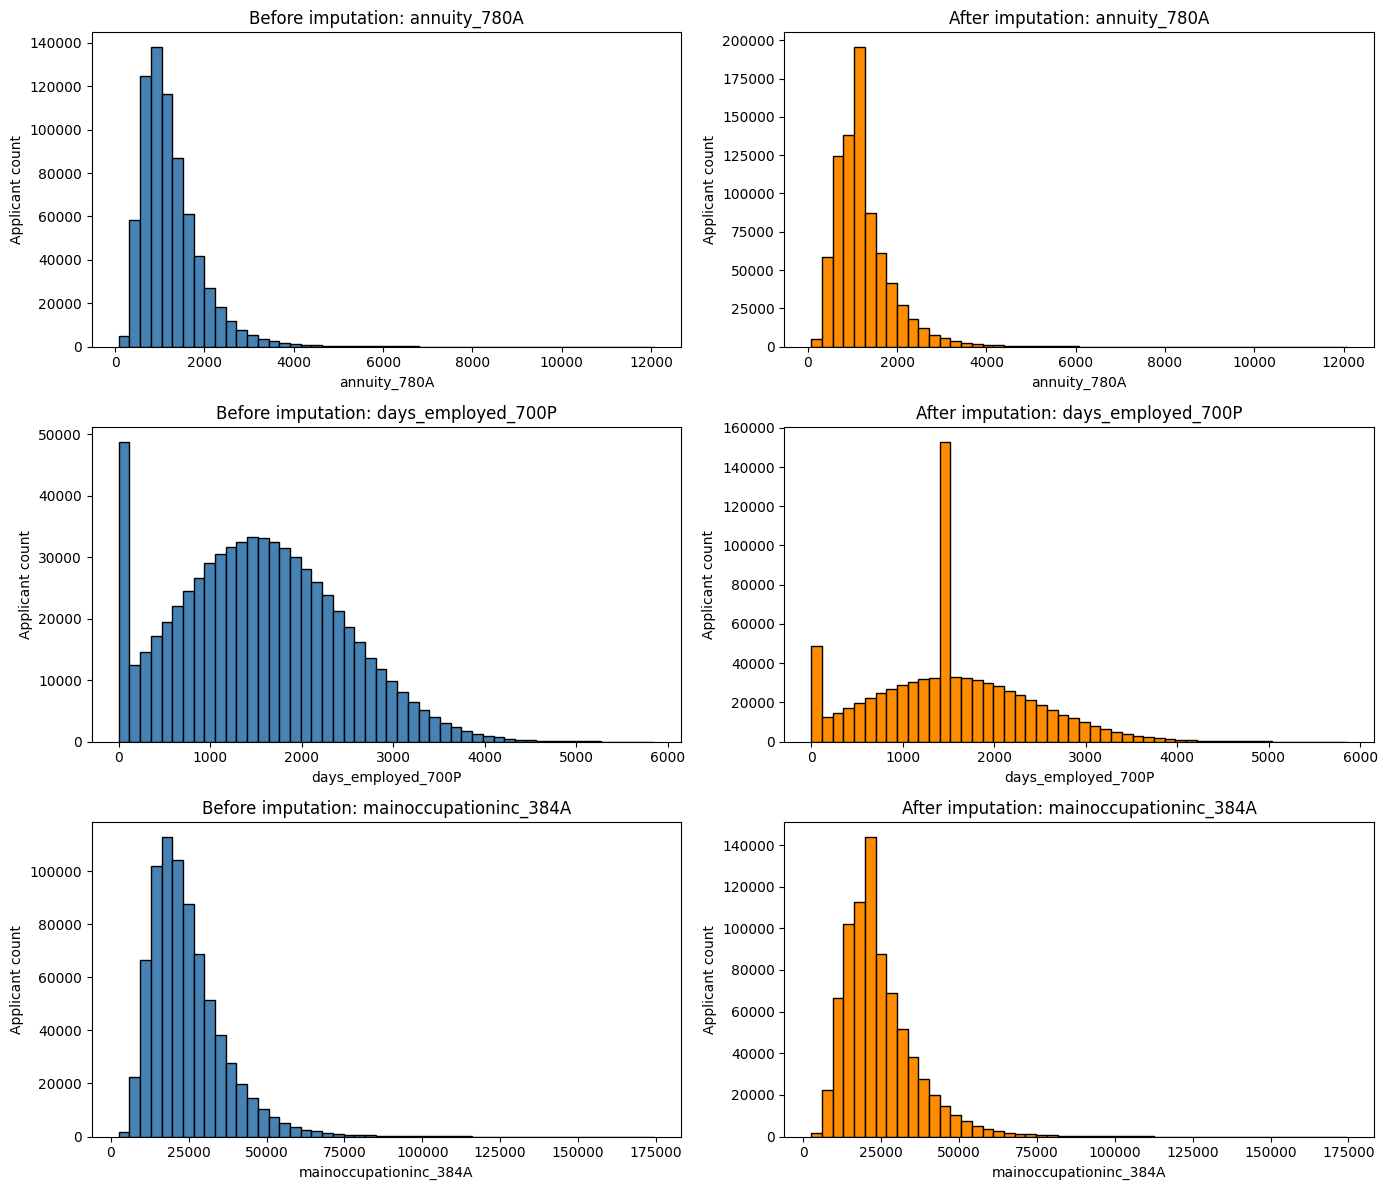

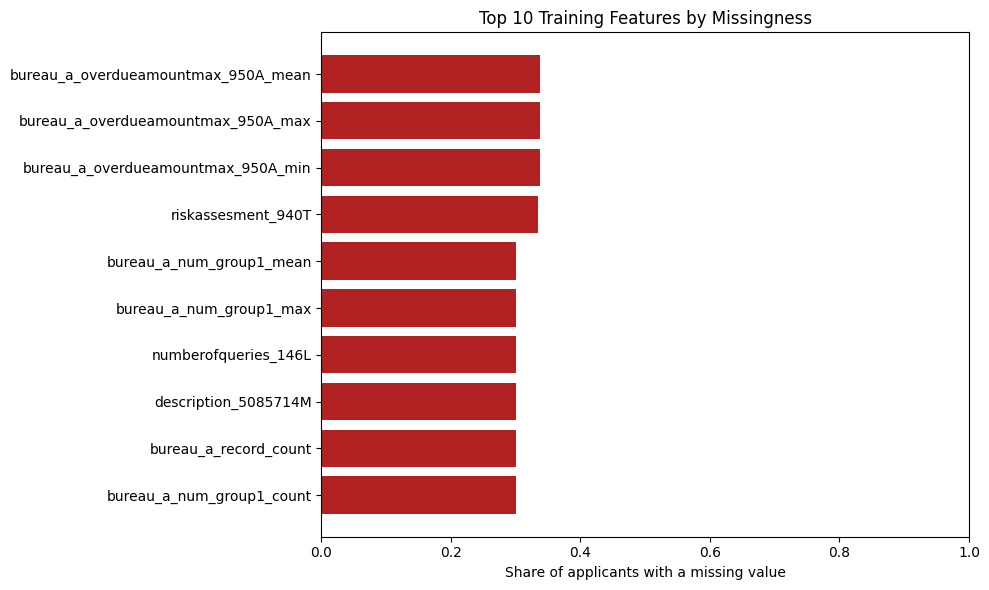

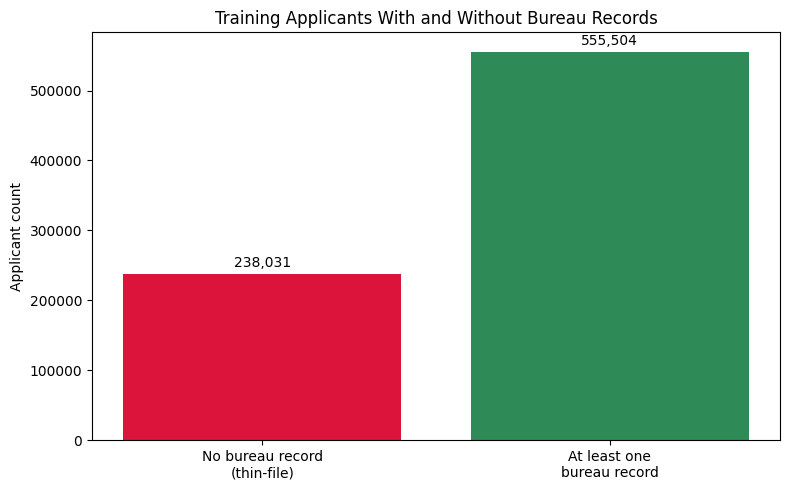

In [9]:
import matplotlib.pyplot as plt
# Visualizations to evaulate the results of the preprocessing pipeline.
plot_columns = [
    "annuity_780A",
    "days_employed_700P",
    "mainoccupationinc_384A"
]

fig, axes = plt.subplots(
    len(plot_columns),
    2,
    figsize=(14, 4 * len(plot_columns))
)

for i, col in enumerate(plot_columns):
    for ax, values, title, color in [
        (axes[i, 0], X_train[col].dropna(), "Before imputation", "steelblue"),
        (axes[i, 1], X_train_ready[col], "After imputation", "darkorange")
    ]:
        ax.hist(values, bins=50, color=color, edgecolor="black")
        ax.set_title(f"{title}: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Applicant count")

plt.tight_layout()
plt.show()


top_missing = (
    X_train.isna()
    .mean()
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
plt.barh(top_missing.index, top_missing, color="firebrick")
plt.title("Top 10 Training Features by Missingness")
plt.xlabel("Share of applicants with a missing value")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


bureau_match = train.loc[
    X_train.index,
    "bureau_a_record_count"
].notna()

counts = [
    (~bureau_match).sum(),
    bureau_match.sum()
]

labels = [
    "No bureau record\n(thin-file)",
    "At least one\nbureau record"
]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=["crimson", "seagreen"])

plt.title("Training Applicants With and Without Bureau Records")
plt.ylabel("Applicant count")

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + 10000,
        f"{count:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
# Save processed data to Google Drive.

processed_data = project_dir / "processed_data"
processed_data.mkdir(exist_ok=True)

X_train_ready.to_csv(
    processed_data / "X_train_ready.csv",
    index=False
)

X_valid_ready.to_csv(
    processed_data / "X_valid_ready.csv",
    index=False
)

X_test_ready.to_csv(
    processed_data / "X_test_ready.csv",
    index=False
)

y_train.to_frame("target").to_csv(
    processed_data / "y_train.csv",
    index=False
)

y_valid.to_frame("target").to_csv(
    processed_data / "y_valid.csv",
    index=False
)

print("Processed data saved to Google Drive.")

Processed data saved to Google Drive.
